In [52]:
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
import numpy as np

In [62]:
df = pd.read_csv("ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])

C:\Users\Cho\AppData\Local\Temp\ipykernel_37700\288974645.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv("ending_club_preprocessed2.csv", parse_dates=['issue_d', 'earliest_cr_line'])


In [80]:
### 파생컬럼 추가

# train/test split 전에 생성(4개 생성)
df['installment_to_income'] = df['installment'] / (df['annual_inc'] / 12) # installment_to_income (월상환부담률)
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc'] #  loan_to_income (대출규모 대비 소득)
df['revol_bal_to_income'] = df['revol_bal'] / df['annual_inc'] #  revol_bal_to_income (회전부채 대비 소득)
df['revol_pressure'] = df['revol_util'] * df['revol_bal'] # revol_pressure (신용압박 지수)

# inf/nan 처리
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income', 'revol_pressure']
for col in new_cols:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)


# 추가 파생변수 생성
df['issue_month'] = df['issue_d'].dt.month
df["earliest_cr_line"] = pd.to_datetime(df["earliest_cr_line"], errors="coerce")
df["earliest_year"] = df["earliest_cr_line"].dt.year
df["credit_history_len"] = df["issue_year"] - df["earliest_year"]
df['dti_x_installment'] = df['dti'] * df['installment_to_income']

In [81]:
df2 = df.copy()

y = df2["target"]
X = df2.drop(columns=["target"])

# 4) train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [88]:
df2.isna().sum().sort_values(ascending = False).head(20)

mths_since_last_record            1052865
mths_since_recent_bc_dlq           958775
mths_since_last_major_derog        924045
mths_since_recent_revol_delinq     832930
mths_since_rcnt_il                 754388
mths_since_last_delinq             634712
mths_since_recent_inq              124121
mo_sin_old_il_acct                  38045
mths_since_recent_bc                12685
dti_x_installment                     414
dti                                   414
installment_to_income                 361
loan_to_income                        361
revol_bal_to_income                   361
pct_tl_nvr_dlq                        154
annual_inc                              0
home_ownership                          0
emp_length                              0
sub_grade                               0
loan_amnt                               0
dtype: int64

In [ ]:
# dti 
X_train["dti"] = X_train.groupby("grade")["dti"].transform(lambda x: x.fillna(x.median())
)
train_dit_medi = X_train.groupby("grade")["dti"].median()
X_test["dti"] = X_test["dti"].fillna(X_test["grade"].map(train_dit_medi))


# 신용 조회, 
cols = [
'mths_since_last_delinq',
'mths_since_last_record',
'mths_since_last_major_derog',
'mths_since_recent_revol_delinq',
'mths_since_recent_bc_dlq',
'mths_since_rcnt_il',
'mths_since_recent_inq',
'mths_since_recent_bc'
]
for col in cols:
    max_val = X_train[col].max()
    X_train[col] = X_train[col].fillna(max_val + 1)
    X_test[col] = X_test[col].fillna(max_val + 1)



## mo_sin_old_il_acct 설명 가장 오래된 할부 계좌 이후 경과 월수
X_train["mo_sin_old_il_acct"] = X_train["mo_sin_old_il_acct"].fillna(0)
X_test["mo_sin_old_il_acct"] = X_test["mo_sin_old_il_acct"].fillna(0)

# pct_tl_nvr_dlq 연체 이력이 한 번도 없는 계좌 비율 (%)
## 중앙값으로 채우기 
medi_dlq = X_train["pct_tl_nvr_dlq"].median()
X_train["pct_tl_nvr_dlq"] = X_train["pct_tl_nvr_dlq"].fillna(medi_dlq)
X_test["pct_tl_nvr_dlq"] = X_test["pct_tl_nvr_dlq"].fillna(medi_dlq)

# 파생변수 결측값 채우기
new_cols = ['installment_to_income', 'loan_to_income', 'revol_bal_to_income', 'revol_pressure', 'dti_x_installment']
for col in new_cols:
    train_median = X_train[col].median()                    # train으로만 계산
    X_train[col] = X_train[col].fillna(train_median)       # train에 적용
    X_test[col] = X_test[col].fillna(train_median)         # test에도 train median 사용

In [ ]:
#결측치 최종 검증
print(X_train.isna().sum().sort_values(ascending = False).head(5))
print(X_test.isna().sum().sort_values(ascending = False).head(5))


loan_amnt      0
term           0
int_rate       0
installment    0
grade          0
dtype: int64
loan_amnt      0
term           0
int_rate       0
installment    0
grade          0
dtype: int64


In [95]:
num_cols = ['int_rate', 'issue_year', 'avg_cur_bal', 'acc_open_past_24mths',
            'loan_amnt', 'dti', 'fico_mid', 'annual_inc', 'num_actv_rev_tl',
            'mort_acc', 'tot_hi_cred_lim', 'total_rev_hi_lim',
            'num_actv_bc_tl', 'num_il_tl', 'total_acc', 'num_rev_tl_bal_gt_0',
            'revol_util', 'revol_bal', 'bc_open_to_buy','mo_sin_old_il_acct',
            'pct_tl_nvr_dlq',
            # mths 계열
            'mths_since_last_delinq',
            'mths_since_last_record',
            'mths_since_last_major_derog',
            'mths_since_recent_revol_delinq',
            'mths_since_recent_bc_dlq',
            'mths_since_rcnt_il',
            'mths_since_recent_inq',
            'mths_since_recent_bc',
            #파생변수 추가
            'installment_to_income', 'loan_to_income', 'revol_bal_to_income', 'issue_month', 'credit_history_len', 'dti_x_installment']

cat_cols = ['sub_grade', 'term', 'emp_length', 'home_ownership', 'verification_status', 'purpose',
            # mths계열 flag 컬럼 추가
            'mths_since_last_delinq_flag',
            'mths_since_last_record_flag',
            'mths_since_last_major_derog_flag',
            'mths_since_recent_revol_delinq_flag',
            'mths_since_recent_bc_dlq_flag',
            'mths_since_rcnt_il_flag',
            'mths_since_recent_inq_flag',
            'mths_since_recent_bc_flag']

used_cols = set(num_cols) | set(cat_cols)
dropped_cols = set(X_train.columns) - used_cols
print(f"제외된 컬럼 수: {len(dropped_cols)}")
print(dropped_cols)

제외된 컬럼 수: 38
{'pub_rec', 'grade', 'num_tl_op_past_12m', 'earliest_cr_line', 'addr_state', 'mo_sin_rcnt_rev_tl_op', 'inq_last_6mths', 'pub_rec_bankruptcies', 'acc_now_delinq', 'tax_liens', 'delinq_amnt', 'initial_list_status', 'mo_sin_old_rev_tl_op', 'num_op_rev_tl', 'installment', 'num_rev_accts', 'num_tl_90g_dpd_24m', 'application_type', 'issue_d', 'total_bal_ex_mort', 'chargeoff_within_12_mths', 'mo_sin_rcnt_tl', 'percent_bc_gt_75', 'revol_pressure', 'num_accts_ever_120_pd', 'total_bc_limit', 'earliest_year', 'bc_util', 'total_il_high_credit_limit', 'collections_12_mths_ex_med', 'delinq_2yrs', 'num_sats', 'open_acc', 'num_bc_sats', 'tot_coll_amt', 'tot_cur_bal', 'num_bc_tl', 'num_tl_30dpd'}


In [96]:
# 파이프 라인 생성 
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

num_pipeline = "passthrough"

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=0.01
    ))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        tree_method="hist",
        eval_metric="auc",
        scale_pos_weight=scale_pos_weight,
        max_depth=6,
        n_estimators=500,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=3,
        gamma=0.1,
        random_state=42
    ))
])

# 전체 데이터로 바로 학습
pipe.fit(X_train, y_train)
print("학습 완료!")

학습 완료!


In [98]:
# 평가
y_prob = pipe.predict_proba(X_test)[:, 1]
threshold = 0.45
pred = (y_prob >= threshold).astype(int)

print("\nTest Accuracy:", accuracy_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, pred))


Test Accuracy: 0.6163758021599625
ROC-AUC: 0.738798669842205

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.58      0.71    203905
         1.0       0.31      0.76      0.44     51655

    accuracy                           0.62    255560
   macro avg       0.61      0.67      0.58    255560
weighted avg       0.79      0.62      0.65    255560



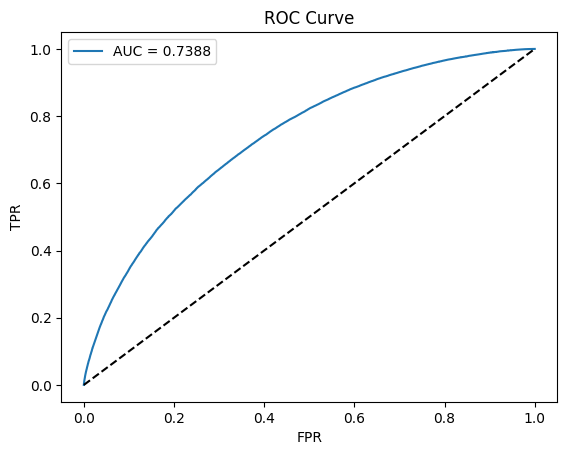

In [99]:
# test 시각화
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [100]:
# feature importance 확인
feature_names = pipe[:-1].get_feature_names_out()
importances = pipe['model'].feature_importances_

importance_df = pd.DataFrame({
    '컬럼': feature_names,
    '중요도': importances
}).sort_values('중요도', ascending=False).reset_index(drop=True)

print(importance_df.head(50))

                                           컬럼       중요도
0                               num__int_rate  0.126080
1                        cat__term_ 36 months  0.115562
2                           cat__sub_grade_A1  0.072351
3           cat__sub_grade_infrequent_sklearn  0.052890
4                     cat__emp_length_unknown  0.025970
5                        cat__term_ 60 months  0.025070
6                cat__home_ownership_MORTGAGE  0.024380
7                               num__fico_mid  0.022478
8                             num__issue_year  0.022123
9                           cat__sub_grade_A2  0.021264
10                   cat__home_ownership_RENT  0.020290
11                          cat__sub_grade_A3  0.018232
12           cat__mths_since_rcnt_il_flag_yes  0.017364
13                     num__dti_x_installment  0.016350
14      cat__verification_status_Not Verified  0.014593
15                  num__acc_open_past_24mths  0.013957
16                              num__mort_acc  0

선택된 피처 수: 20


['num__int_rate',
 'cat__term_ 36 months',
 'cat__mths_since_rcnt_il_flag_no',
 'cat__term_ 60 months',
 'cat__sub_grade_A1',
 'cat__sub_grade_A2',
 'cat__sub_grade_A3',
 'num__issue_year',
 'cat__sub_grade_A4',
 'num__fico_mid',
 'cat__home_ownership_RENT',
 'cat__emp_length_unknown',
 'cat__home_ownership_MORTGAGE',
 'cat__verification_status_Not Verified',
 'num__mort_acc',
 'num__dti',
 'num__acc_open_past_24mths',
 'num__avg_cur_bal',
 'num__num_actv_rev_tl',
 'cat__addr_state_WA']